<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L03-ETSDA/notebooks/L03_2_BasicToolbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
files.upload()

Saving aus_production.csv to aus_production (13).csv


{'aus_production (13).csv': b'"ds","Beer","Tobacco","Bricks","Cement","Electricity","Gas"\n1956-01-01,284,5225,189,465,3923,5\n1956-04-01,213,5178,204,532,4436,6\n1956-07-01,227,5297,208,561,4806,7\n1956-10-01,308,5681,197,570,4418,6\n1957-01-01,262,5577,187,529,4339,5\n1957-04-01,228,5651,214,604,4811,7\n1957-07-01,236,5317,227,603,5259,7\n1957-10-01,320,6152,222,582,4735,6\n1958-01-01,272,5758,199,554,4608,5\n1958-04-01,233,5641,229,620,5196,7\n1958-07-01,237,5802,249,646,5609,8\n1958-10-01,313,6265,234,637,4977,6\n1959-01-01,261,5478,208,573,4883,5\n1959-04-01,227,5892,251,673,5744,7\n1959-07-01,250,5952,267,690,6035,8\n1959-10-01,314,6597,255,681,5514,6\n1960-01-01,286,5980,242,621,5387,6\n1960-04-01,227,6154,268,698,6211,8\n1960-07-01,260,5478,290,753,6659,8\n1960-10-01,311,6716,277,728,5983,7\n1961-01-01,295,6022,241,688,5709,6\n1961-04-01,233,6070,253,737,6458,7\n1961-07-01,257,6303,265,742,6875,8\n1961-10-01,339,6693,236,692,6162,6\n1962-01-01,279,6072,229,637,6098,6\n1962-04-0

In [3]:
df_full = pd.read_csv("/content/aus_production.csv")
df_full['Fecha'] = pd.period_range(start='1956-01', periods=len(df_full), freq='Q')
df_full = df_full.set_index('Fecha')
df_full.index = df_full.index.to_timestamp()
df_full

,ds,Beer,Tobacco,Bricks,Cement,Electricity,Gas
Fecha,,,,,,,
1956-01-01,1956-01-01,284,5225.0,189.0,465,3923,5
1956-04-01,1956-04-01,213,5178.0,204.0,532,4436,6
1956-07-01,1956-07-01,227,5297.0,208.0,561,4806,7
1956-10-01,1956-10-01,308,5681.0,197.0,570,4418,6
1957-01-01,1957-01-01,262,5577.0,187.0,529,4339,5
...,...,...,...,...,...,...,...
2009-04-01,2009-04-01,398,NaN,NaN,2160,57471,238
2009-07-01,2009-07-01,419,NaN,NaN,2325,58394,252
2009-10-01,2009-10-01,488,NaN,NaN,2273,57336,210


In [4]:
columna = 'Bricks' # Columna de interés, se seguirá utilizando durante el resto del cuaderno

df = df_full[columna].to_frame()
df = df.dropna()
df.head()

,Bricks
Fecha,
1956-01-01,189.0
1956-04-01,204.0
1956-07-01,208.0
1956-10-01,197.0
1957-01-01,187.0


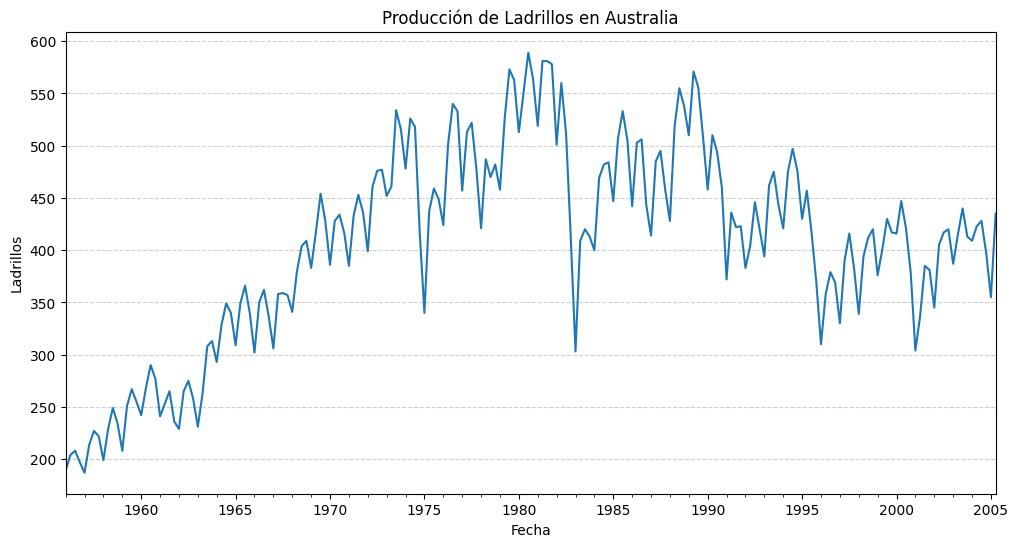

In [5]:
# Gráfico
plt.figure(figsize=(12, 6))
df[columna].plot()

# Etiquetas
plt.title('Producción de Ladrillos en Australia')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [6]:
frecuencia = 'Q'
pasos = 33

# Creando un dataframe de todos los forecasts
inicioForecast = df.index[-1].to_period(frecuencia) + 1 # to_period solo es necesario si convertiste el índice en timestamp para poder sumar
forecastIndex = pd.period_range(start=inicioForecast, periods=pasos, freq=frecuencia)
dfForecast = pd.DataFrame(index=forecastIndex)
dfForecast.head()

""
2005Q3
2005Q4
2006Q1
2006Q2
2006Q3


In [7]:
valorPromedio = df[columna].mean()

dfForecast['Promedio'] = valorPromedio
dfForecast.head()

,Promedio
2005Q3,405.494949
2005Q4,405.494949
2006Q1,405.494949
2006Q2,405.494949
2006Q3,405.494949


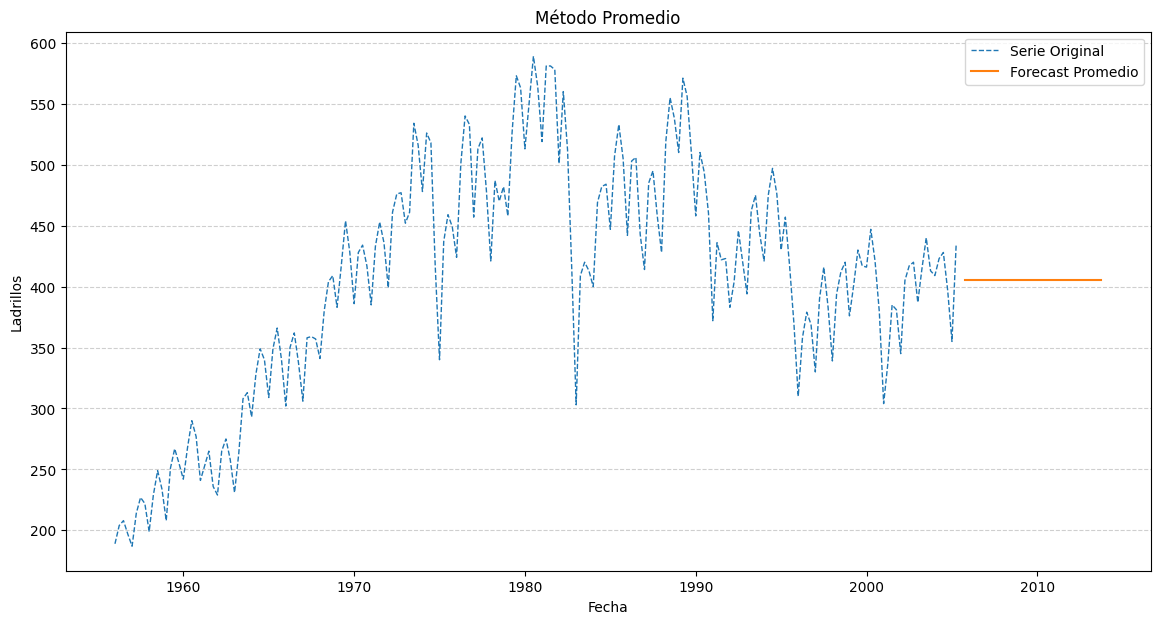

In [8]:
# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(df[columna], label='Serie Original', linestyle='--', lw = 1)
plt.plot(dfForecast['Promedio'], label='Forecast Promedio')

# Etiquetas
plt.title('Método Promedio')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [9]:
ultimoValor = df[columna].iloc[-1]

dfForecast['Naive'] = ultimoValor
dfForecast.head()

,Promedio,Naive
2005Q3,405.494949,435.0
2005Q4,405.494949,435.0
2006Q1,405.494949,435.0
2006Q2,405.494949,435.0
2006Q3,405.494949,435.0


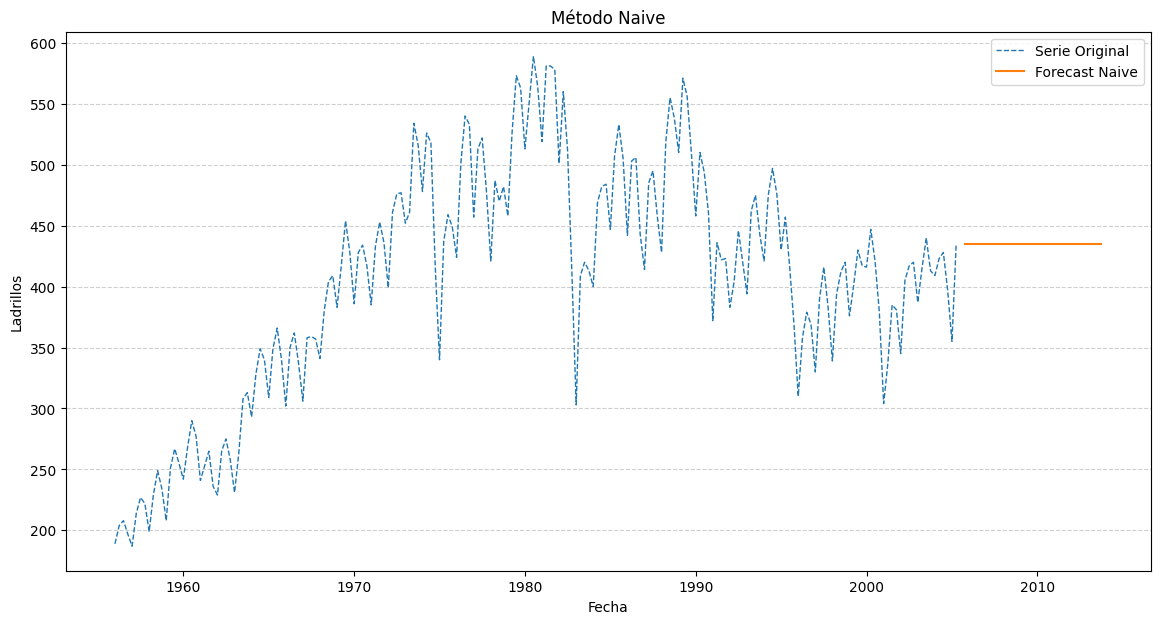

In [10]:
# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(df[columna], label='Serie Original', linestyle='--', lw = 1)
plt.plot(dfForecast['Naive'], label='Forecast Naive')

# Etiquetas
plt.title('Método Naive')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [11]:
estacionalidad = 4

# Obtener los últimos valores de cada estación
patronEstacional = df[columna].iloc[-estacionalidad:]

# Repeat the seasonal pattern to fill the forecast
dfForecast['NaiveEst'] = list(patronEstacional) * (pasos // estacionalidad) + list(patronEstacional)[0:(pasos % estacionalidad)]
dfForecast.head()

,Promedio,Naive,NaiveEst
2005Q3,405.494949,435.0,428.0
2005Q4,405.494949,435.0,397.0
2006Q1,405.494949,435.0,355.0
2006Q2,405.494949,435.0,435.0
2006Q3,405.494949,435.0,428.0


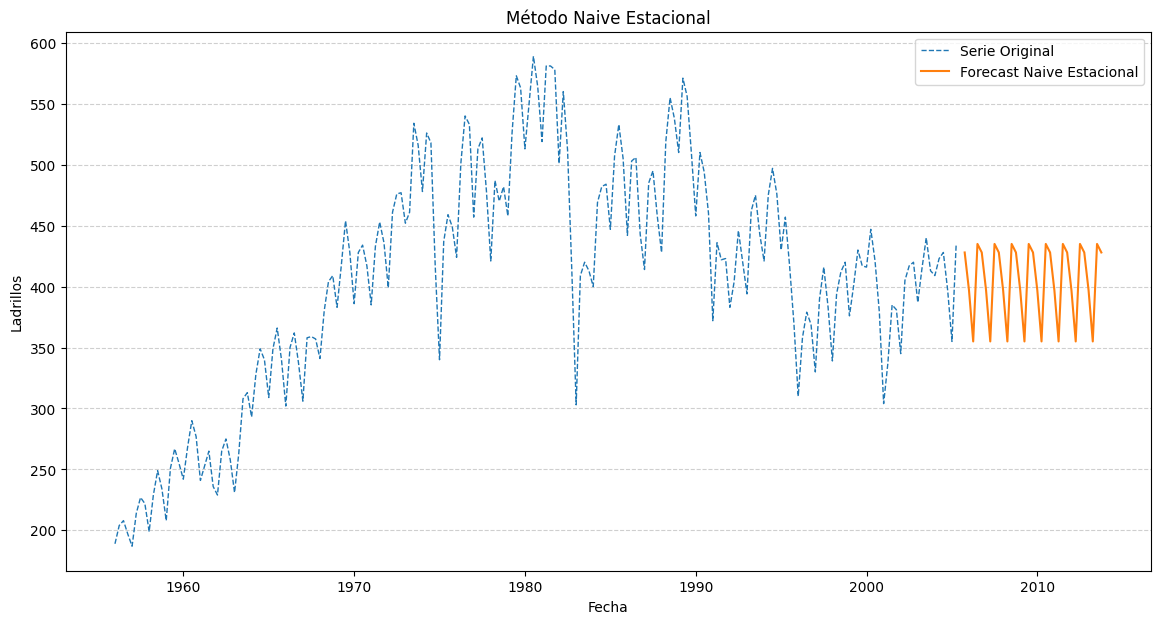

In [12]:
# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(df[columna], label='Serie Original', linestyle='--', lw = 1)
plt.plot(dfForecast['NaiveEst'], label='Forecast Naive Estacional')

# Etiquetas
plt.title('Método Naive Estacional')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [13]:
# Calculando el drift
valorInicial = df[columna].iloc[0]
valorFinal = df[columna].iloc[-1]
numPeriodos = len(df[columna])
drift = (valorFinal - valorInicial) / (numPeriodos - 1) #(y2-y1)/(x2-x1)

# Generar valores con el drift
dfForecast['Drift'] = [(valorFinal + (i + 1) * drift) for i in range(pasos)]
dfForecast.head()

,Promedio,Naive,NaiveEst,Drift
2005Q3,405.494949,435.0,428.0,436.248731
2005Q4,405.494949,435.0,397.0,437.497462
2006Q1,405.494949,435.0,355.0,438.746193
2006Q2,405.494949,435.0,435.0,439.994924
2006Q3,405.494949,435.0,428.0,441.243655


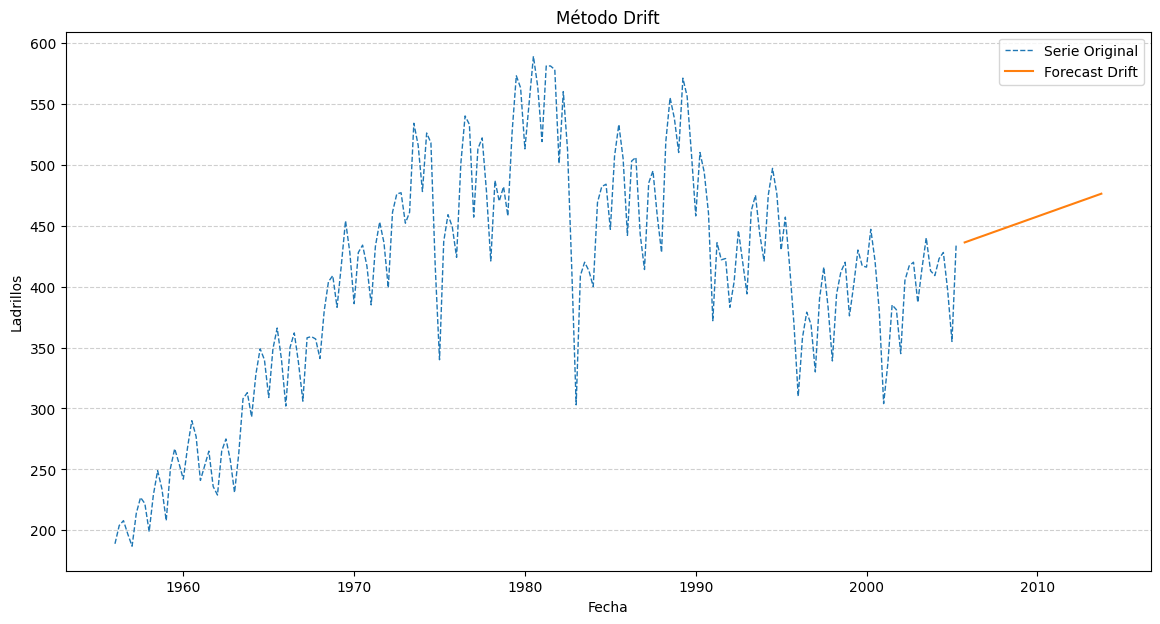

In [14]:
# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(df[columna], label='Serie Original', linestyle='--', lw = 1)
plt.plot(dfForecast['Drift'], label='Forecast Drift')

# Etiquetas
plt.title('Método Drift')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

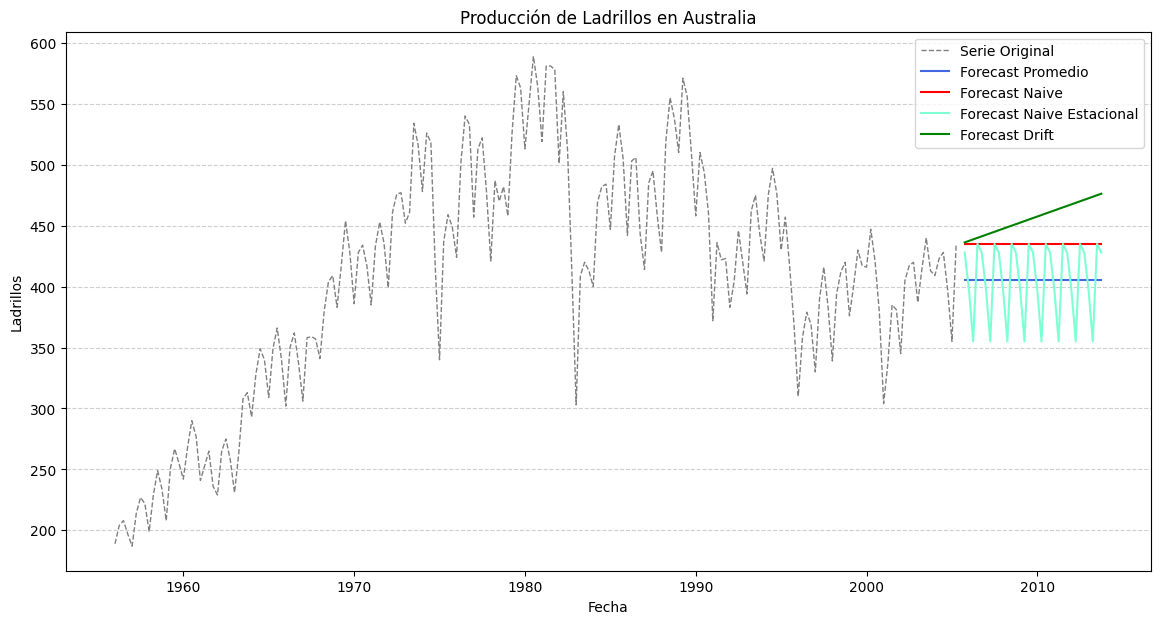

In [15]:
# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(df[columna], label='Serie Original', linestyle='--', lw = 1, color = 'gray')
plt.plot(dfForecast['Promedio'], label='Forecast Promedio', color = 'royalblue')
plt.plot(dfForecast['Naive'], label='Forecast Naive', color = 'red')
plt.plot(dfForecast['NaiveEst'], label='Forecast Naive Estacional', color = 'aquamarine')
plt.plot(dfForecast['Drift'], label='Forecast Drift', color = 'green')

# Etiquetas
plt.title('Producción de Ladrillos en Australia')
plt.xlabel('Fecha')
plt.ylabel('Ladrillos')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()